In [90]:
##-- load libraries --##
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [91]:
##-- load data --##
data = pd.read_csv("survival.csv", index_col = 0)
data.head()

,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
1,3.0,306,2,74,1,1.0,90.0,100.0,1175.0,NaN
2,3.0,455,2,68,1,0.0,90.0,90.0,1225.0,15.0
3,3.0,1010,1,56,1,0.0,90.0,90.0,NaN,15.0
4,5.0,210,2,57,1,1.0,90.0,60.0,1150.0,11.0
5,1.0,883,2,60,1,0.0,100.0,90.0,NaN,0.0


- inst: institution code
- time: survival time in days
- status (censoring status): 0 = censored , 1 = dead
- age: age in years
- ......
- meal.cal = calories consumed at means
- wt.loss: weight loss in last six months

In [92]:
print(f"Data Shape: {data.shape}")

Data Shape: (228, 10)


In [93]:
data['status'].value_counts()

status
2    165
1     63
Name: count, dtype: int64

In [94]:
data['sex'].value_counts()

sex
1    138
2     90
Name: count, dtype: int64

In [95]:
data = data[['time', 'status', 'age', 'sex', 'ph.ecog', 'ph.karno','pat.karno', 'meal.cal', 'wt.loss']]
data["status"] = data["status"] - 1 # convert to 1 and 0
data["sex"] = data["sex"] - 1 # convert to 1 and 0
data.head()

,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
1,306,1,74,0,1.0,90.0,100.0,1175.0,NaN
2,455,1,68,0,0.0,90.0,90.0,1225.0,15.0
3,1010,0,56,0,0.0,90.0,90.0,NaN,15.0
4,210,1,57,0,1.0,90.0,60.0,1150.0,11.0
5,883,1,60,0,0.0,100.0,90.0,NaN,0.0


In [96]:
data.isnull().sum()

time          0
status        0
age           0
sex           0
ph.ecog       1
ph.karno      1
pat.karno     3
meal.cal     47
wt.loss      14
dtype: int64

In [97]:
data["ph.karno"].fillna(data["ph.karno"].mean(), inplace = True)
data["pat.karno"].fillna(data["pat.karno"].mean(), inplace = True)
data["meal.cal"].fillna(data["meal.cal"].mean(), inplace = True)
data["wt.loss"].fillna(data["wt.loss"].mean(), inplace = True)

data.dropna(inplace=True)

data["ph.ecog"] = data["ph.ecog"].astype("int64")

data.isnull().sum()

time         0
status       0
age          0
sex          0
ph.ecog      0
ph.karno     0
pat.karno    0
meal.cal     0
wt.loss      0
dtype: int64

In [98]:
data.shape

(227, 9)

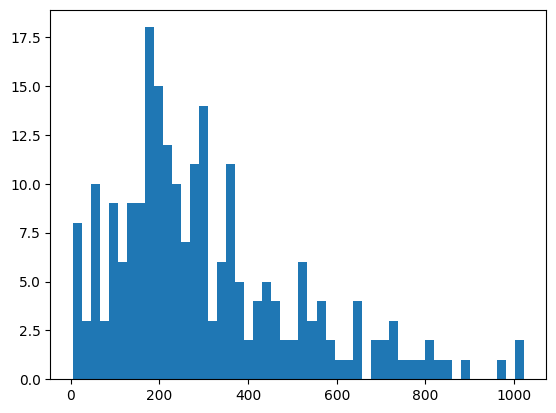

In [99]:
T = data["time"]
E = data["status"]
plt.hist(T, bins = 50) # the entire range of T is divided into 50 slices
plt.show()

## Fitting a non-parametric model [Kaplan Meier Curve]
### KaplanMeierFitter 
- It is a tool from the lifelines library.

- It estimates the Kaplan–Meier survival function, which shows the probability of “surviving” (not experiencing the event) over time.


- The Kaplan–Meier model is a non-parametric, univariate survival model that estimates the probability of surviving past each time point without assuming a distribution.

- It does not assume the data follows a specific probability distribution (like normal, exponential, Weibull, etc.). Instead, it estimates things directly from the observed data.

<Axes: xlabel='timeline'>

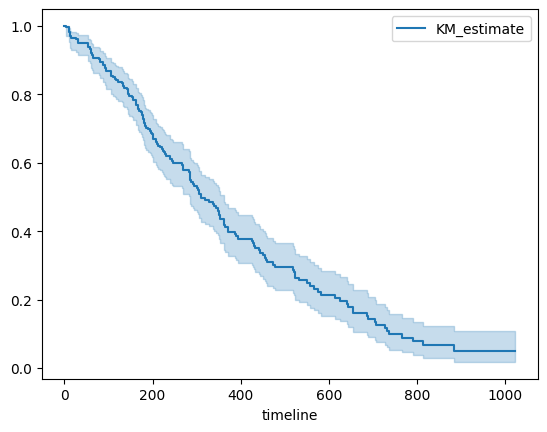

In [100]:
T = data["time"]
E = data["status"] # censored or dead

kmf = KaplanMeierFitter()
kmf.fit(durations = T, event_observed = E)
kmf.plot_survival_function()

# y-axis = survival probability, x-axis = time.

Text(0.5, 1.0, 'Survival function')

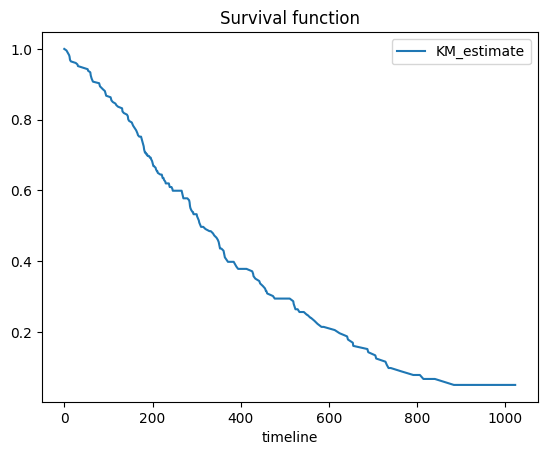

In [101]:
# another way of plotting the Kaplan–Meier survival curve
kmf.survival_function_.plot()
plt.title('Survival function')

<Axes: xlabel='timeline'>

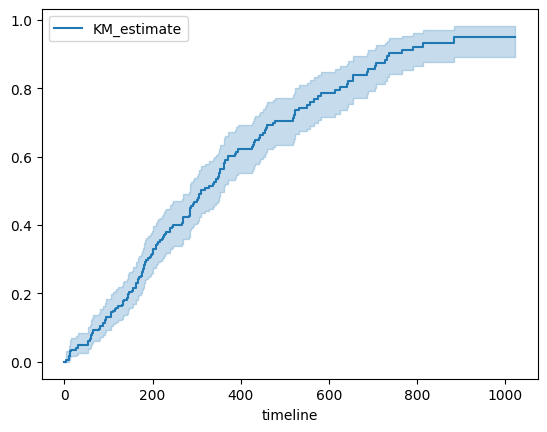

In [102]:
# plots the cumulative density function (CDF) of events over time.
kmf.plot_cumulative_density()

- In Kaplan–Meier survival analysis, median_survival_times_ (in lifelines) gives you the median survival time — the time at which the survival probability first drops to 50%.

- By what time will 50% of the population have experienced the event?

In [103]:
from lifelines.utils import median_survival_times

median_ = kmf.median_survival_time_
median_confidence_interval_ = median_survival_times(kmf.confidence_interval_)
print(f"Median Survival Time: {median_}")

Median Survival Time: 310.0


In [104]:
print(median_confidence_interval_)

     KM_estimate_lower_0.95  KM_estimate_upper_0.95
0.5                   284.0                   361.0


Text(0.5, 1.0, 'Survival of Different Gender Group')

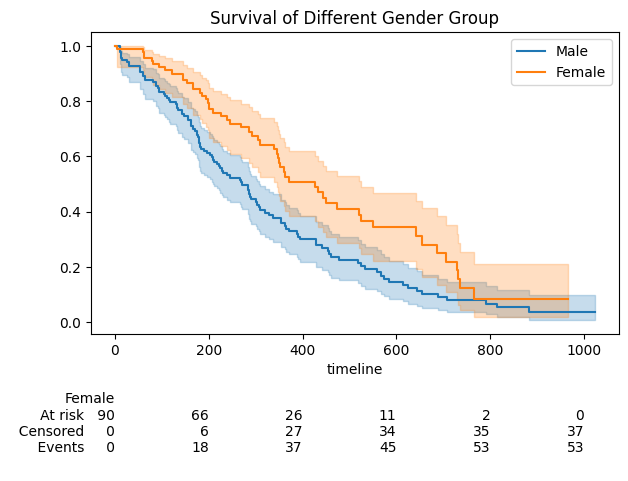

In [105]:
ax = plt.subplot(1, 1, 1)   # 1 row, 1 column, pick the 1st subplot

m = (data["sex"] == 0)

kmf.fit(durations = T[m], event_observed = E[m], label = "Male")
kmf.plot_survival_function(ax = ax)

kmf.fit(T[~m], event_observed = E[~m], label = "Female")
kmf.plot_survival_function(ax = ax, at_risk_counts = True)

plt.title("Survival of Different Gender Group")

In [106]:
data['ph.ecog'].value_counts()

ph.ecog
1    113
0     63
2     50
3      1
Name: count, dtype: int64

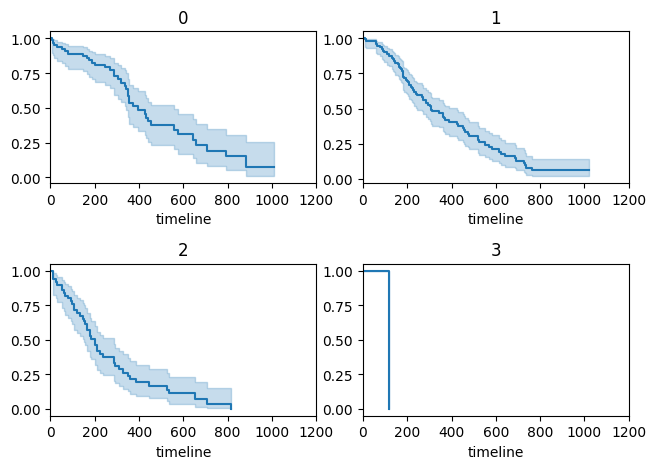

In [107]:
ecog_types = data.sort_values(by = ['ph.ecog'])["ph.ecog"].unique()

for i, ecog_types in enumerate(ecog_types):
  ax = plt.subplot(2, 2, i + 1)
  ix = data['ph.ecog'] == ecog_types
  kmf.fit(T[ix], E[ix], label = ecog_types)
  kmf.plot_survival_function(ax = ax, legend = False)
  plt.title(ecog_types)
  plt.xlim(0, 1200)
  
plt.tight_layout()

In [108]:
data['ph.ecog'].value_counts()

ph.ecog
1    113
0     63
2     50
3      1
Name: count, dtype: int64

In [109]:
data = data[data["ph.ecog"] != 3]
data.shape

(226, 9)

In [110]:
data['ph.ecog'].value_counts()

ph.ecog
1    113
0     63
2     50
Name: count, dtype: int64

## Fitting Cox Proportional Hazard Model

- One of the most widely used models in survival analysis.

- A semi-parametric survival model.

- Models the effect of covariates (features like age, loan amount, income, credit score, etc.) on the hazard rate.

- Unlike Kaplan–Meier (which is univariate and non-parametric), Cox can handle multiple predictors (independent variables like features, inputs, covariates) that are used to explain or predict an outcome

- `Hazard`: The risk of the event happening at a specific time, given it hasn’t happened yet.
    - Example: Hazard = “chance a loan defaults (when a borrower does not pay back the loan or interest on time) this month if it hasn’t yet.”


- `Hazard ratio (HR)`: The ratio of the hazard (risk of an event) between two groups or conditions at any point in time.
    - HR = 1 → no difference in risk between groups.

    - HR > 1 → the first group has a higher risk of the event.

    - HR < 1 → the first group has a lower risk of the event.


In the current dataset

- `Hazard` is defined as the slope of the survival curve- a measure of how rapidly subjects are dying.

- `Hazard Ratio` compares two treatments. If the hazard ratio is 2.0, then the rate of deaths in one treatement group is twice in the other group.


In [111]:
data.head()

,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
1,306,1,74,0,1,90.0,100.0,1175.000000,9.831776
2,455,1,68,0,0,90.0,90.0,1225.000000,15.000000
3,1010,0,56,0,0,90.0,90.0,928.779006,15.000000
4,210,1,57,0,1,90.0,60.0,1150.000000,11.000000
5,883,1,60,0,0,100.0,90.0,928.779006,0.000000


In [112]:
# converts categorical variables into one-hot encoded variables
dummies_ecog = pd.get_dummies(data["ph.ecog"], prefix = 'ecog')
dummies_ecog.head(4)

,ecog_0,ecog_1,ecog_2
1,False,True,False
2,True,False,False
3,True,False,False
4,False,True,False


In [113]:
dummies_ecog = dummies_ecog[["ecog_1", "ecog_2"]]
data = pd.concat([data, dummies_ecog], axis = 1)
data = data.drop("ph.ecog", axis = 1)
data.head()

,time,status,age,sex,ph.karno,pat.karno,meal.cal,wt.loss,ecog_1,ecog_2
1,306,1,74,0,90.0,100.0,1175.000000,9.831776,True,False
2,455,1,68,0,90.0,90.0,1225.000000,15.000000,False,False
3,1010,0,56,0,90.0,90.0,928.779006,15.000000,False,False
4,210,1,57,0,90.0,60.0,1150.000000,11.000000,True,False
5,883,1,60,0,100.0,90.0,928.779006,0.000000,False,False


In [114]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(data, duration_col = 'time', event_col = 'status')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 226 total observations, 63 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 226
number of events observed = 163
   partial log-likelihood = -721.02
         time fit was run = 2025-09-15 20:06:17 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.01      1.01      0.01           -0.01            0.03                0.99                1.03
sex       -0.58      0.56      0.17           -0.92           -0.25                0.40                0.78
ph.karno   0.02      1.02      0.01           -0.00            0.03                1.00                1.03
pat.karno -0.01      0.99      0.01           -0.03            0.00                0.97                1.00
meal.cal   0.00      1.00      0.00           -0.00            0.00                1.00                1.00
wt.loss   -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
ecog_1     0.62      1.86      0.24            0.15            1.09                1.17                2.97
ecog_2     1.20      3.31      0.37            0.46            1.93                1.59                6.89

           cmp to     z      p  -log2(p)
covariate                               
age          0.00  1.33   0.18      2.44
sex          0.00 -3.41 <0.005     10.58
ph.karno     0.00  1.64   0.10      3.29
pat.karno    0.00 -1.77   0.08      3.70
meal.cal     0.00  0.06   0.95      0.07
wt.loss      0.00 -1.73   0.08      3.57
ecog_1       0.00  2.60   0.01      6.76
ecog_2       0.00  3.19 <0.005      9.46
---
Concordance = 0.65
Partial AIC = 1458.05
log-likelihood ratio test = 36.08 on 8 df
-log2(p) of ll-ratio test = 15.85

Below is a forest plot from a Cox Proportional Hazards model.

- Squares = estimated effect of each variable (log hazard ratio).

- Horizontal lines = 95% confidence interval.

- Dashed vertical line at 0 = “no effect” (HR=1).

- If CI crosses 0 → effect not significant.

- Points right of 0 → higher hazard (worse survival).

- Points left of 0 → lower hazard (better survival).

In your plot:

- ECOG_1, ECOG_2 → higher hazard (worse survival).

- Sex → lower hazard (better survival).

- Others (age, wt.loss, etc.) → near 0, mostly not significant.

<Axes: xlabel='log(HR) (95% CI)'>

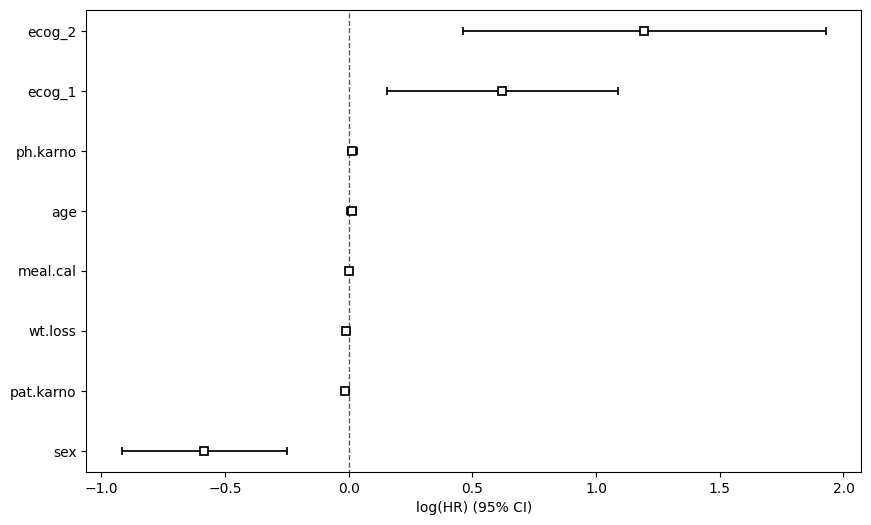

In [115]:
plt.subplots(figsize = (10, 6))
cph.plot()

In [116]:
data.head()

,time,status,age,sex,ph.karno,pat.karno,meal.cal,wt.loss,ecog_1,ecog_2
1,306,1,74,0,90.0,100.0,1175.000000,9.831776,True,False
2,455,1,68,0,90.0,90.0,1225.000000,15.000000,False,False
3,1010,0,56,0,90.0,90.0,928.779006,15.000000,False,False
4,210,1,57,0,90.0,60.0,1150.000000,11.000000,True,False
5,883,1,60,0,100.0,90.0,928.779006,0.000000,False,False


Text(0, 0.5, 'Survival Probability')

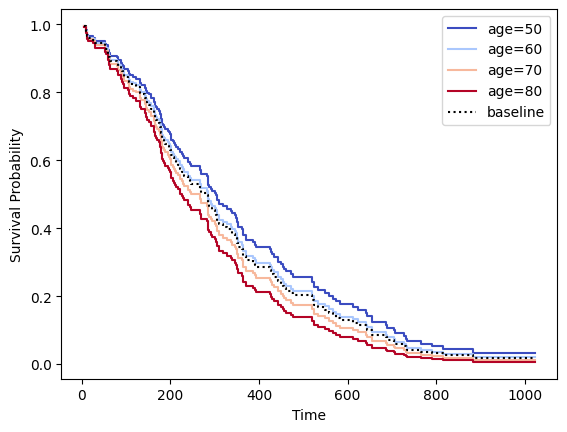

In [117]:
cph.plot_partial_effects_on_outcome(covariates = 'age', values = [50, 60, 70, 80], cmap = 'coolwarm')
plt.xlabel('Time')
plt.ylabel('Survival Probability')

# shows how survival probability changes over time for a given age (50, 60, 70, 80), with all other covariates held constant.

Text(0, 0.5, 'Survival Probability')

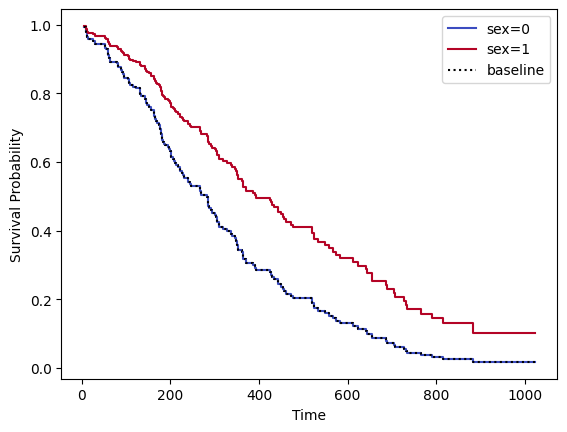

In [118]:
cph.plot_partial_effects_on_outcome(covariates = 'sex', values = [0, 1], cmap = 'coolwarm')
plt.xlabel('Time')
plt.ylabel('Survival Probability')

In [119]:
# diagnostic check to make sure your CoxPH model is valid
# p ≥ 0.05 -> Good -> No evidence the proportional hazards (PH) assumption is violated.
# p < 0.05 -> Bad -> Covariate likely violates PH assumption (effect changes over time).

cph.check_assumptions(data, p_value_threshold = 0.05)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 226 total observations, 63 right-censored observations>
         test_name = proportional_hazard_test

---
                test_statistic    p  -log2(p)
age       km              0.42 0.52      0.95
          rank            0.18 0.67      0.58
ecog_1    km              1.57 0.21      2.25
          rank            1.41 0.23      2.09
ecog_2    km              1.20 0.27      1.87
          rank            0.86 0.35      1.50
meal.cal  km              5.32 0.02      5.57
          rank            4.73 0.03      5.08
pat.karno km              0.21 0.64      0.64
          rank            0.17 0.68      0.55
ph.karno  km              3.62 0.06      4.13
          rank            3.07 0.08      3.65
sex       km              2.62 0.11      3.25
          rank            2.50 0.11      3.14
wt.loss   km              0.02 0.89      0.17
          rank            0.06 0.81      0.31



1. Variable 'meal.cal' failed the non-proportional test: p-value is 0.0210.

   Advice 1: the functional form of the variable 'meal.cal' might be incorrect. That is, there may
be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'meal.cal' using pd.cut, and then specify it in
`strata=['meal.cal', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#

[]

The variable meal.cal breaks the proportional hazards rule in your Cox model. This means its effect on the risk changes over time, instead of staying constant.

In [120]:
# Check whether each variable in your Cox model follows the proportional hazards assumption.
# PH assumption: the effect of a variable on the hazard (risk) stays constant over time.

# cph: your fitted Cox model.
# data: the dataset you used to fit the model.
# time_transform='rank': a method to detect time-varying effects. It ranks the times to help test the assumption.


# test_statistic -> measures how much the variable violates PH.
# p -> if < 0.05, the variable does NOT satisfy the PH assumption.
# Example: If meal.cal has p-value 0.021, it means its effect changes over time, so PH assumption is violated.

from lifelines.statistics import proportional_hazard_test

results = proportional_hazard_test(cph, data, time_transform='rank')
results.print_summary(decimals=3, model="untransformed variables")

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 226 total observations, 63 right-censored observations>
         test_name = proportional_hazard_test

---
           test_statistic    p  -log2(p)
age                  0.18 0.67      0.58
ecog_1               1.41 0.23      2.09
ecog_2               0.86 0.35      1.50
meal.cal             4.73 0.03      5.08
pat.karno            0.17 0.68      0.55
ph.karno             3.07 0.08      3.65
sex                  2.50 0.11      3.14
wt.loss              0.06 0.81      0.31

## Parametric [Acclerated Failure Time Model (AFT)]

- The AFT model is a parametric survival model that assumes a specific statistical distribution for survival times (like exponential, Weibull, log-normal, or log-logistic).

- Instead of modeling hazard like the Cox model, AFT models the effect of covariates on survival time directly.

In [121]:
# import parametric univariate survival models from lifelines
from lifelines import WeibullFitter, ExponentialFitter, LogNormalFitter, LogLogisticFitter

# instantiate each fitter (create model objects)
wb = WeibullFitter()        # Weibull distribution
ex = ExponentialFitter()    # Exponential distribution
log = LogNormalFitter()     # Log-normal distribution
loglogis = LogLogisticFitter()  # Log-logistic distribution

# list of all models
models = [wb, ex, log, loglogis]

# loop through each model to fit to the data and print AIC
for model in models:
    model.fit(durations=data["time"], event_observed=data["status"])
    
    # print the AIC (Akaike Information Criterion) for the model
    # lower AIC = better model fit (penalizes for complexity)
    print("The AIC value for", model.__class__.__name__, "is", model.AIC_)

The AIC value for WeibullFitter is 2286.140229521957
The AIC value for ExponentialFitter is 2301.5875633782243
The AIC value for LogNormalFitter is 2318.1118082857615
The AIC value for LogLogisticFitter is 2300.6601651026126


In [122]:
data.head()

,time,status,age,sex,ph.karno,pat.karno,meal.cal,wt.loss,ecog_1,ecog_2
1,306,1,74,0,90.0,100.0,1175.000000,9.831776,True,False
2,455,1,68,0,90.0,90.0,1225.000000,15.000000,False,False
3,1010,0,56,0,90.0,90.0,928.779006,15.000000,False,False
4,210,1,57,0,90.0,60.0,1150.000000,11.000000,True,False
5,883,1,60,0,100.0,90.0,928.779006,0.000000,False,False


In [123]:
# import parametric covariates (multivariate) survival models from lifelines
from lifelines import WeibullAFTFitter

weibull_aft = WeibullAFTFitter() 

# data = pandas DataFrame containing survival times, event status, and predictors
# duration_col = name of the column with survival times
# event_col = name of the column indicating if the event occurred (1) or censored (0)
weibull_aft.fit(data, duration_col='time', event_col='status', formula="age + sex") # use age and sex to predict how long each subject survives; default uses all

# rounds numeric output to 3 decimal places for readability
weibull_aft.print_summary(3)

<lifelines.WeibullAFTFitter: fitted with 226 total observations, 63 right-censored observations>
             duration col = 'time'
                event col = 'status'
   number of observations = 226
number of events observed = 163
           log-likelihood = -1134.640
         time fit was run = 2025-09-15 20:06:18 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                   
lambda_ Intercept  6.659   779.773     0.448           5.782           7.536             324.378            1874.499
        age       -0.012     0.988     0.007          -0.026           0.002               0.975               1.002
        sex        0.369     1.447     0.127           0.120           0.619               1.128               1.856
rho_    Intercept  0.288     1.333     0.062           0.165           0.410               1.180               1.506

                   cmp to      z       p  -log2(p)
param   covariate                                 
lambda_ Intercept   0.000 14.880 <0.0005   163.950
        age         0.000 -1.739   0.082     3.608
        sex         0.000  2.906   0.004     8.093
rho_    Intercept   0.000  4.614 <0.0005    17.947
---
Concordance = 0.600
AIC = 2277.280
log-likelihood ratio test = 12.860 on 2 df
-log2(p) of ll-ratio test = 9.277

In [124]:
print(weibull_aft.median_survival_time_)
print(weibull_aft.mean_survival_time_)

276.336441968354
334.3473262491721


<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

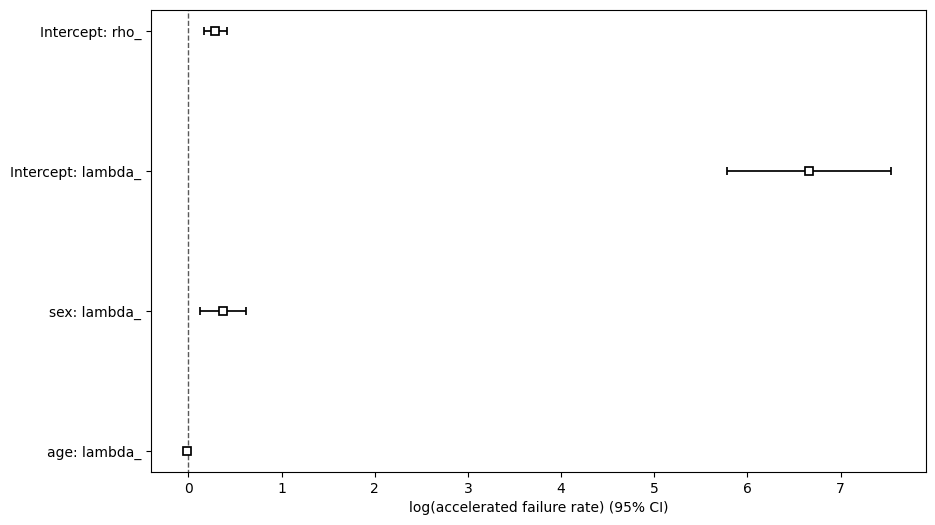

In [125]:
# create a new figure and set its size (width=10, height=6)
plt.subplots(figsize=(10, 6))
weibull_aft.plot()

<Axes: >

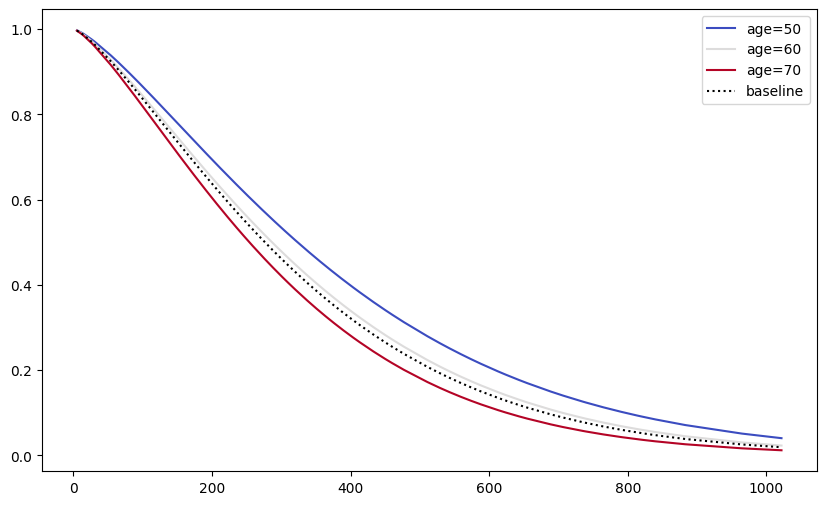

In [126]:
plt.figure(figsize=(10, 6))

# plot the effect of a single covariate ('age') on survival probability
weibull_aft.plot_partial_effects_on_outcome('age', range(50, 80, 10), cmap='coolwarm')